# SIRI-ET Compare
This Jupyter Notebook compares the data quality of DELFI SIRI-ET stream with the original communication logs of an ITCS of IVU. It requires two input files:
- `data/itcs.log` The communication logs of the IVU ITCS
- `data/siriet/*.xml` At least one recorded SIRI-ET dump of DELFI

## 1. Step: Extraction of ITCS Data
The ITCS log contains mixed text block logs and XML dumps of the VDV454-AUS data. The extraction block parses the XML contents and builds a dict in following structure:

```python
{
    'JourneyRef': [
        datetime(...),
        datetime(...),
        datetime(...),
        ...
    ]
}
```

This structure contains each journey and all timestamps, when data have been delivered for this journey.

In [1]:
from __future__ import annotations

from collections import defaultdict
from datetime import datetime
from typing import DefaultDict
from xml.etree import ElementTree as ET


# Result structure:
# {
#     "FahrtBezeichner": [datetime(...), datetime(...)]
# }
journey_timestamps: DefaultDict[str, list[datetime]] = defaultdict(list)


def process_xml(xml_text: str) -> None:
    """Extract timestamps and trip identifiers from a single XML block."""

    try:
        root: ET.Element = ET.fromstring(xml_text)
    except ET.ParseError:
        # Ignore malformed XML blocks
        return

    confirmation: ET.Element | None = root.find("./Bestaetigung")
    if confirmation is None:
        return

    timestamp_text: str | None = confirmation.attrib.get("Zst")
    if timestamp_text is None:
        return

    timestamp: datetime = datetime.fromisoformat(timestamp_text)

    # Only process IstFahrt elements.
    # SollFahrt elements are intentionally ignored.
    for istfahrt in root.iter("IstFahrt"):
        trip_identifier: ET.Element | None = istfahrt.find(
            "./FahrtRef/FahrtID/FahrtBezeichner"
        )

        if trip_identifier is None or not trip_identifier.text:
            continue

        journey_timestamps[trip_identifier.text.strip()].append(timestamp)


xml_lines: list[str] = []
collecting_xml: bool = False

with open("data/itcs.log", encoding="ISO-8859-1") as log_file:
    for line in log_file:
        xml_start: int = line.find("<?xml")

        # Start of a new XML block
        if xml_start >= 0:
            if xml_lines:
                process_xml("".join(xml_lines))

            xml_lines = [line[xml_start:]]
            collecting_xml = True
            continue

        if collecting_xml:
            # Detect the beginning of the next log entry
            is_log_line: bool = (
                len(line) >= 23
                and line[4] == "-"
                and line[7] == "-"
                and line[10] == " "
            )

            if is_log_line:
                process_xml("".join(xml_lines))
                xml_lines = []
                collecting_xml = False
            else:
                xml_lines.append(line)

# Process final XML block
if xml_lines:
    process_xml("".join(xml_lines))

# Ensure chronological ordering
for timestamps in journey_timestamps.values():
    timestamps.sort()

journey_timestamps = dict(journey_timestamps)

print(f"Number of unique journeys: {len(journey_timestamps)}")
print(
    f"Number of timestamp records: "
    f"{sum(len(timestamps) for timestamps in journey_timestamps.values())}"
)

Number of unique journeys: 759
Number of timestamp records: 7464


## 2. Step: Extraction of SIRI-ET Data
The SIRI-ET dumps contain a SIRI ServiceDelivery object. The extraction block parses the XMLs and extracts for each JourneyRef the RecordedAt timestamp into a structure like that:

```python
{
    'JourneyRef': {
        'response_timestamp': datetime(...),'
        'recorded_at': datetime(...)
    }        
    ...
}
```
The `recorded_at` is the timestamp when the message from the ITCS has arrived at the SIRI-ET broker. The `response_timestamp` represents the timestamp, when the updates became published in the SIRI-ET data.

In [2]:
from __future__ import annotations

from collections import defaultdict
from dataclasses import dataclass
from datetime import datetime, timedelta
from pathlib import Path
from typing import DefaultDict
from xml.etree.ElementTree import iterparse


@dataclass(slots=True)
class JourneyObservation:
    response_timestamp: datetime
    recorded_at: datetime


ACTIVE_JOURNEY_BUFFER = timedelta(minutes=1)


def parse_datetime(value: str) -> datetime:
    """Parse an ISO-8601 timestamp."""
    return datetime.fromisoformat(
        value.strip().replace("Z", "+00:00")
    )


def strip_namespace(tag: str) -> str:
    """Remove XML namespace from a tag name."""
    return tag.split("}", 1)[-1]


# --------------------------------------------------
# Result structure
# --------------------------------------------------
#
# {
#     VehicleJourneyRef: [
#         JourneyObservation(...),
#         JourneyObservation(...),
#     ]
# }
#
journey_observations: DefaultDict[
    str,
    list[JourneyObservation],
] = defaultdict(list)


# --------------------------------------------------
# Analysis metadata
# --------------------------------------------------

analysis_start: datetime | None = None
analysis_end: datetime | None = None


# --------------------------------------------------
# Collect files
# --------------------------------------------------

siriet_directory = Path("data/siriet")

xml_files = sorted(
    file
    for file in siriet_directory.iterdir()
    if file.is_file()
)

total_files = len(xml_files)
num_siri_files = total_files

print(
    f"Found {total_files:,} SIRI-ET files to process."
)


# --------------------------------------------------
# Parse all SIRI snapshots
# --------------------------------------------------

for current_file_index, xml_file in enumerate(
    xml_files,
    start=1,
):

    if (
        current_file_index == 1
        or current_file_index % 100 == 0
        or current_file_index == total_files
    ):
        progress = (
            current_file_index
            / total_files
            * 100
        )

        print(
            f"Processed "
            f"{current_file_index:,}/{total_files:,} files "
            f"({progress:.1f}%)"
        )

    response_timestamp: datetime | None = None

    for _, element in iterparse(
        xml_file,
        events=("end",),
    ):
        tag = strip_namespace(element.tag)

        # --------------------------------------------------
        # File-level ResponseTimestamp
        # --------------------------------------------------

        if (
            response_timestamp is None
            and tag == "ResponseTimestamp"
            and element.text
        ):
            response_timestamp = parse_datetime(
                element.text
            )

            if analysis_start is None:
                analysis_start = response_timestamp
            else:
                analysis_start = min(
                    analysis_start,
                    response_timestamp,
                )

            if analysis_end is None:
                analysis_end = response_timestamp
            else:
                analysis_end = max(
                    analysis_end,
                    response_timestamp,
                )

        # --------------------------------------------------
        # EstimatedVehicleJourney
        # --------------------------------------------------

        if tag != "EstimatedVehicleJourney":
            continue

        recorded_at: datetime | None = None
        vehicle_journey_ref: str | None = None

        departure_candidates: list[datetime] = []
        arrival_candidates: list[datetime] = []

        for child in element.iter():

            child_tag = strip_namespace(
                child.tag
            )

            # ----------------------------------------------
            # Observation timestamp
            # ----------------------------------------------

            if (
                child_tag == "RecordedAtTime"
                and child.text
                and recorded_at is None
            ):
                recorded_at = parse_datetime(
                    child.text
                )

            # ----------------------------------------------
            # Journey identifier
            # ----------------------------------------------

            elif (
                child_tag == "VehicleJourneyRef"
                and child.text
            ):
                vehicle_journey_ref = (
                    child.text.strip()
                )

            # ----------------------------------------------
            # Journey timing
            # ----------------------------------------------

            elif (
                child_tag == "EstimatedDepartureTime"
                and child.text
            ):
                departure_candidates.append(
                    parse_datetime(child.text)
                )

            elif (
                child_tag == "AimedDepartureTime"
                and child.text
            ):
                departure_candidates.append(
                    parse_datetime(child.text)
                )

            elif (
                child_tag == "EstimatedArrivalTime"
                and child.text
            ):
                arrival_candidates.append(
                    parse_datetime(child.text)
                )

            elif (
                child_tag == "AimedArrivalTime"
                and child.text
            ):
                arrival_candidates.append(
                    parse_datetime(child.text)
                )

        journey_observations[
            vehicle_journey_ref
        ].append(
            JourneyObservation(
                response_timestamp=response_timestamp,
                recorded_at=recorded_at,
            )
        )

        # Release memory while streaming
        element.clear()


# --------------------------------------------------
# Validate analysis window
# --------------------------------------------------

if (
    analysis_start is None
    or analysis_end is None
):
    raise RuntimeError(
        "No valid ResponseTimestamp found in SIRI files."
    )


# --------------------------------------------------
# Sort observations chronologically
# --------------------------------------------------

for observations in journey_observations.values():

    observations.sort(
        key=lambda observation:
        observation.response_timestamp
    )


journey_observations = dict(
    journey_observations
)


# --------------------------------------------------
# Existing ITCS matching functionality
# --------------------------------------------------

matched_itcs_journeys: set[str] = set()

for siri_journey in journey_observations:

    for itcs_journey in journey_timestamps:

        if siri_journey.startswith(
            itcs_journey
        ) and any(
            analysis_start <= ts <= analysis_end for ts in journey_timestamps[itcs_journey]
        ):
            matched_itcs_journeys.add(
                itcs_journey
            )
            break

# --------------------------------------------------
# ITCS journeys not present in SIRI
# --------------------------------------------------

missing_itcs_journeys = (
    set(journey_timestamps.keys())
    - matched_itcs_journeys
)

# --------------------------------------------------
# Statistics
# --------------------------------------------------

print()

print(
    f"Analysis window: "
    f"{analysis_start.isoformat()} "
    f"to "
    f"{analysis_end.isoformat()}"
)

print(
    f"Number of SIRI snapshots: "
    f"{num_siri_files:,}"
)

print(
    f"Number of unique SIRI journeys: "
    f"{len(journey_observations):,}"
)

print(
    f"Number of journeys from ITCS: "
    f"{len(matched_itcs_journeys):,}"
)

print(
    f"Number of ITCS journeys not present in SIRI: "
    f"{len(missing_itcs_journeys):,}"
)

print(
    f"Number of observations: "
    f"{sum(len(v) for v in journey_observations.values()):,}"
)

Found 486 SIRI-ET files to process.
Processed 1/486 files (0.2%)
Processed 100/486 files (20.6%)
Processed 200/486 files (41.2%)
Processed 300/486 files (61.7%)
Processed 400/486 files (82.3%)
Processed 486/486 files (100.0%)

Analysis window: 2026-06-13T07:49:59.042000+00:00 to 2026-06-13T15:58:06.335000+00:00
Number of SIRI snapshots: 486
Number of unique SIRI journeys: 19,010
Number of journeys from ITCS: 580
Number of ITCS journeys not present in SIRI: 179
Number of observations: 2,200,020


## 3. Step: Metrics
Out of the collected data, following metrics are calculated:
- Assimilation Latency: This is the time which an ITCS update takes to be recorded by the SIRI-ET sink. It is **not** the time when the update becomes visible!
- Propagation Latency: This is the time range which an ITCS updates takes to be visible in SIRI-ET data.
- Snapshot Staleness: Difference between `ResponseTimestamp` and `RecordedAt` of a journey in a SIRI-ET snapshot.
- Future ITCS Updates: Number of updates the ITCS has sent after the last publication of a journey in a SIRI-ET snapshot.
- Lost ITCS Updates: Number of updates the ITCS has sent, but never appeared in a SIRI-ET snapshot.


## Results
Matched observations: 68118

## Assimilation Latency (ITCS → SIRI Data Sink)
- Mean    : 3.152 s
- StdDev  : 0.145 s
- Max     : 3.981 s
- P50     : 3.128 s
- P60     : 3.152 s
- P70     : 3.173 s
- P80     : 3.207 s
- P90     : 3.322 s
- P95     : 3.459 s
- P99     : 3.773 s
- Samples : 62330

## Propagation Latency (ITCS → SIRI Visibility)
- Mean    : 160.551 s
- StdDev  : 104.900 s
- Max     : 600.527 s
- P50     : 151.671 s
- P60     : 179.101 s
- P70     : 216.049 s
- P80     : 254.101 s
- P90     : 299.101 s
- P95     : 342.827 s
- P99     : 422.904 s
- Samples : 5744

## Snapshot Staleness
- Mean    : 2361.295 s
- StdDev  : 2219.314 s
- Max     : 9662.466 s
- P50     : 1614.688 s
- P60     : 2471.655 s
- P70     : 3481.209 s
- P80     : 4584.627 s
- P90     : 5890.771 s
- P95     : 6639.136 s
- P99     : 7492.840 s
- Samples : 68118

## Future ITCS Updates
- Mean : 7.829
- Max  : 62

## Lost ITCS Updates
- Total ITCS updates  : 5,744
- Propagated updates  : 5,744
- L

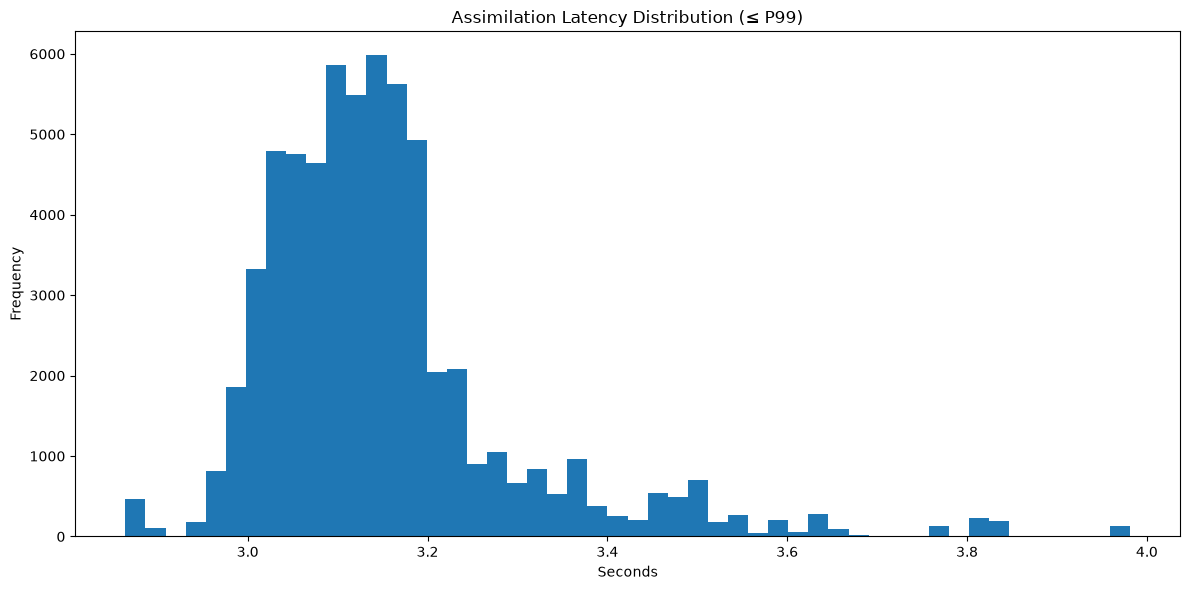

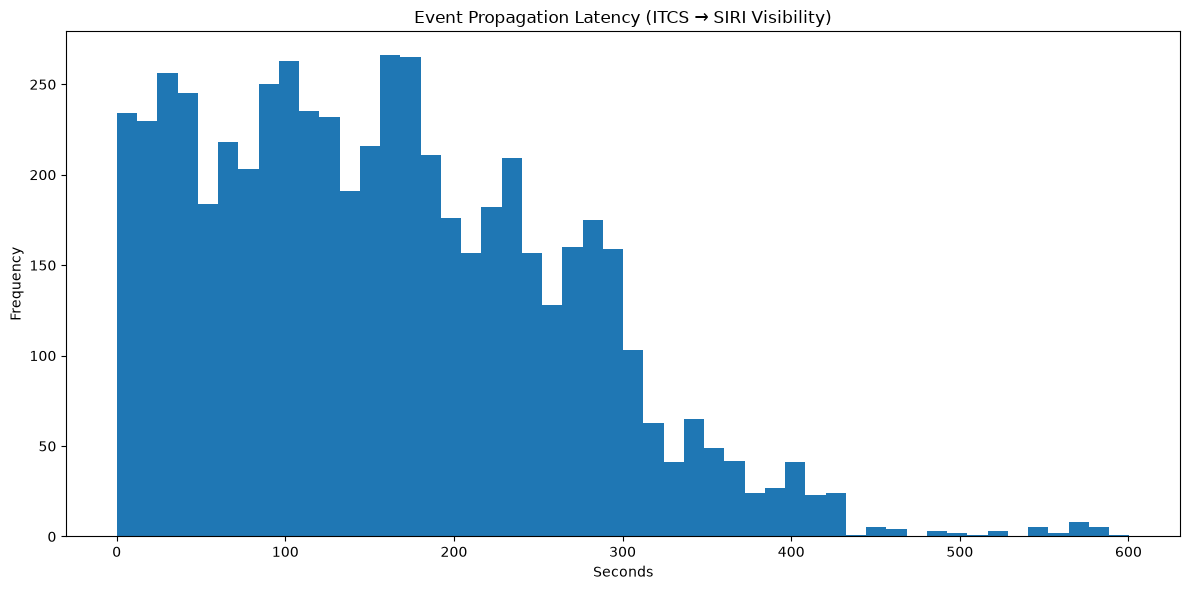

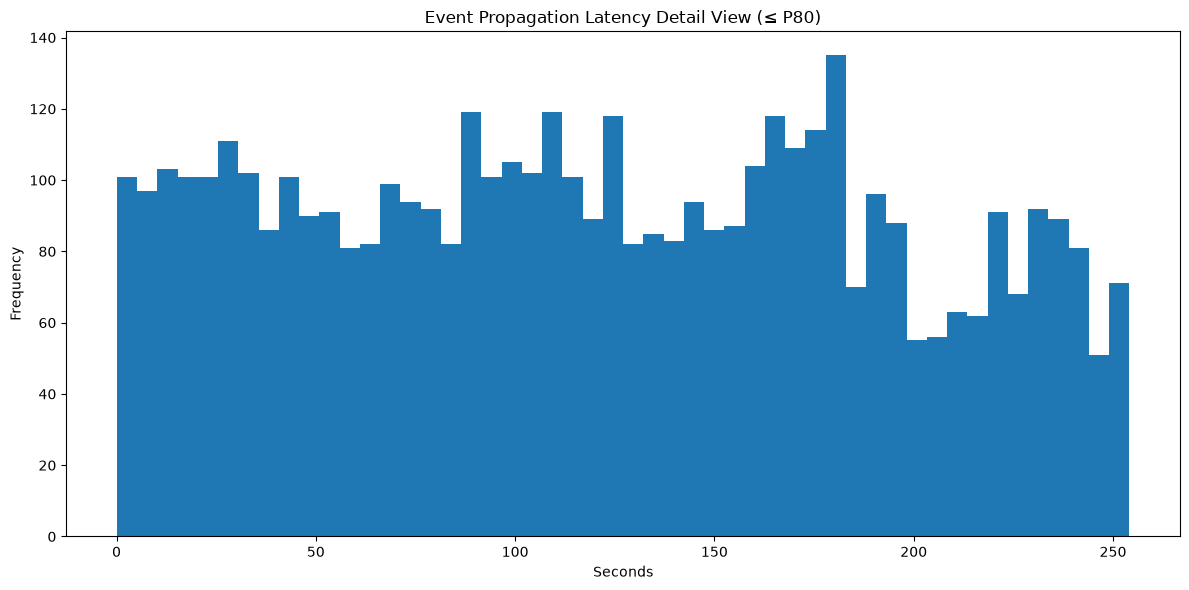

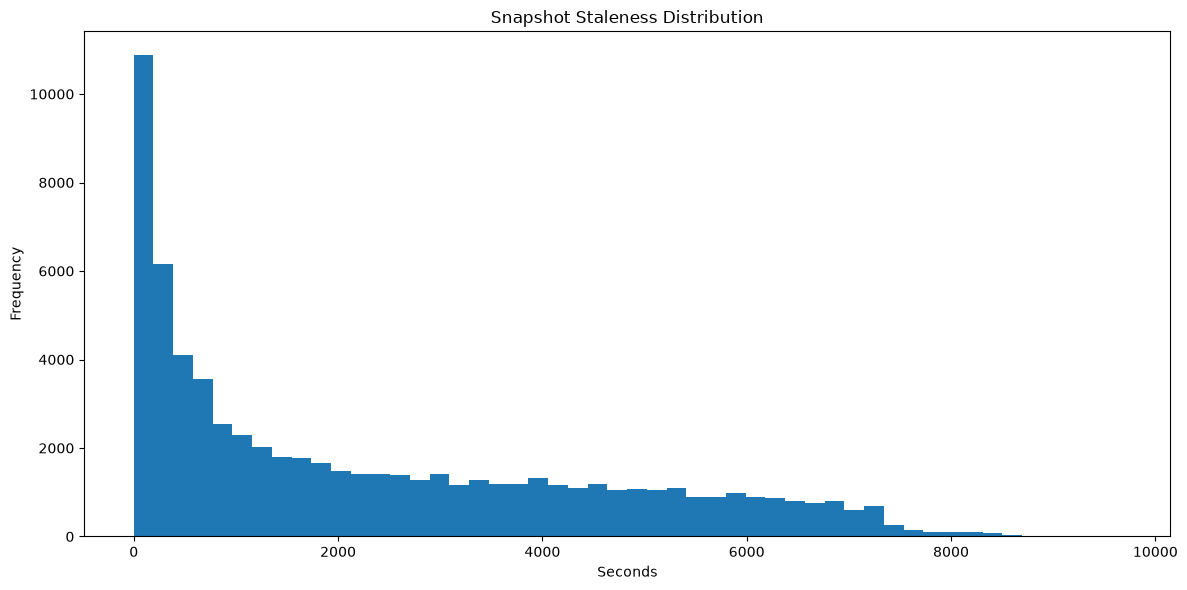

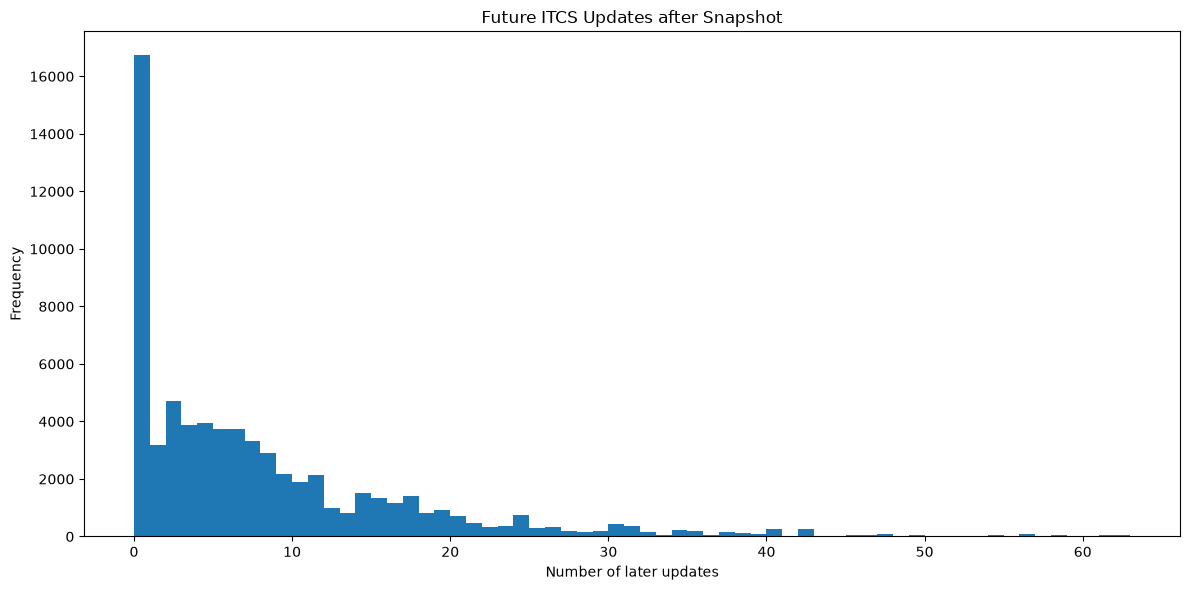

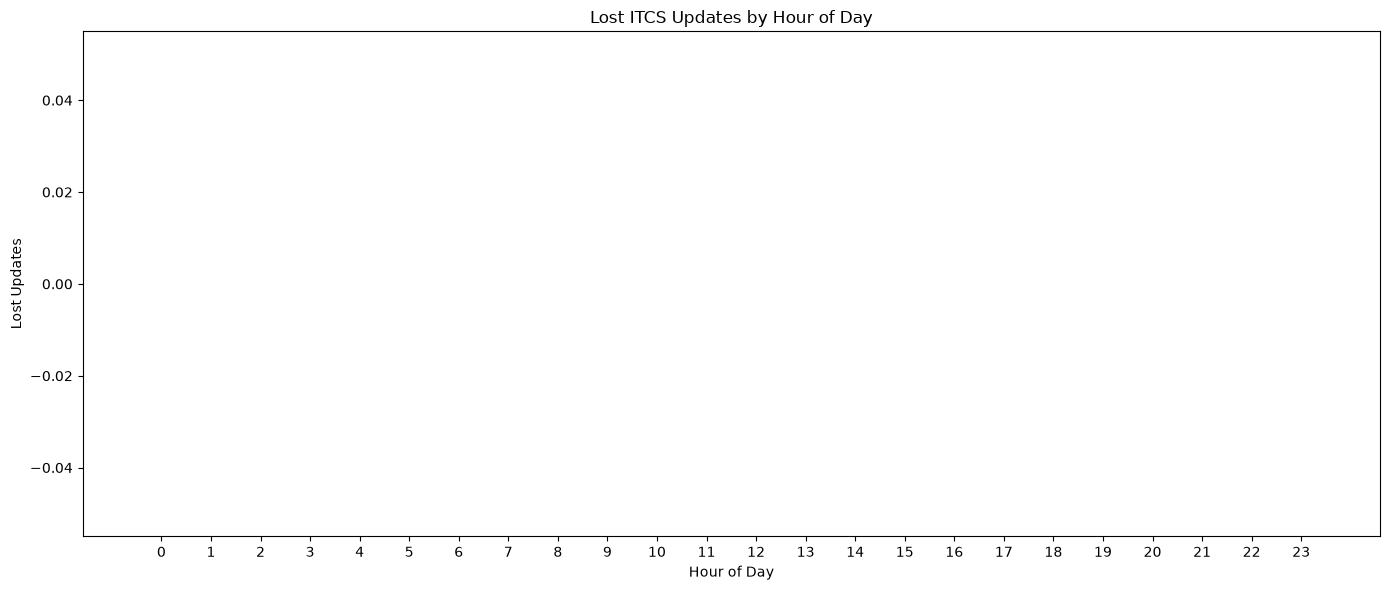

In [5]:
from __future__ import annotations

from statistics import mean, stdev
from typing import List, Optional
from collections import Counter
from datetime import timedelta

import matplotlib.pyplot as plt


# --------------------------------------------------
# Inputs
# --------------------------------------------------
# trip_timestamps: dict[str, list[datetime]]
# journey_observations: dict[str, list[JourneyObservation]]
# --------------------------------------------------


assimilation_latency_seconds: List[float] = []
propagation_latency_seconds: List[float] = []
snapshot_staleness_seconds: List[float] = []
updates_after_snapshot: List[int] = []

matched_observations: int = 0

# --------------------------------------------------
# Lost ITCS update analysis
# --------------------------------------------------

total_itcs_updates = 0
total_itcs_journeys = 0
propagated_itcs_updates = 0
propagated_itcs_journeys = 0

lost_updates_per_hour: Counter[int] = Counter()
lost_updates_per_journey: Counter[str] = Counter()


# --------------------------------------------------
# Percentile (robust linear interpolation)
# --------------------------------------------------

def percentile(
    values: list[float],
    p: float,
) -> float:

    if not values:
        return 0.0

    vals = sorted(values)

    if len(vals) == 1:
        return vals[0]

    idx = (len(vals) - 1) * p

    lo = int(idx)
    hi = min(lo + 1, len(vals) - 1)

    weight = idx - lo

    return vals[lo] + (
        (vals[hi] - vals[lo]) * weight
    )


# --------------------------------------------------
# Statistics helper
# --------------------------------------------------

def compute_stats(
    values: list[float],
) -> dict[str, float]:

    if not values:
        return {
            "mean": 0.0,
            "stddev": 0.0,
            "max": 0.0,
            "p50": 0.0,
            "p60": 0.0,
            "p70": 0.0,
            "p80": 0.0,
            "p90": 0.0,
            "p95": 0.0,
            "p99": 0.0,
        }

    return {
        "mean": mean(values),
        "stddev": (
            stdev(values)
            if len(values) > 1
            else 0.0
        ),
        "max": max(values),

        "p50": percentile(values, 0.50),
        "p60": percentile(values, 0.60),
        "p70": percentile(values, 0.70),
        "p80": percentile(values, 0.80),
        "p90": percentile(values, 0.90),
        "p95": percentile(values, 0.95),
        "p99": percentile(values, 0.99),
    }


# --------------------------------------------------
# Look for completely Unpropagated Journeys
# --------------------------------------------------

journeys_that_should_be_observed = [
    journey_id
    for journey_id, timestamps in journey_timestamps.items()
    if any(
        analysis_start <= ts <= analysis_end
        for ts in timestamps
    )
]

total_itcs_journeys = len(journeys_that_should_be_observed)

journeys_that_are_not_observed = [
    item for item in journeys_that_should_be_observed
    if not any(key.startswith(item) for key in journey_observations.keys())
]

propagated_itcs_journeys = total_itcs_journeys - len(journeys_that_are_not_observed)

# --------------------------------------------------
# Core computation
# --------------------------------------------------

for siri_journey, observations in journey_observations.items():

    matching_itcs_journey: Optional[str] = next(
        (
            itcs_journey
            for itcs_journey in journey_timestamps
            if siri_journey.startswith(
                itcs_journey
            )
        ),
        None,
    )

    if matching_itcs_journey is None:
        continue

    itcs_updates = [
        timestamp
        for timestamp in journey_timestamps[
            matching_itcs_journey
        ]
        if (
            analysis_start + timedelta(minutes=5)
            <= timestamp
            <= analysis_end - timedelta(minutes=5)
        )
    ]

    if not itcs_updates:
        continue

    # --------------------------------------------------
    # Event propagation + lost update analysis
    # --------------------------------------------------

    for itcs_timestamp in itcs_updates:

        total_itcs_updates += 1

        first_siri_after_itcs = next(
            (
                obs.response_timestamp
                for obs in observations
                if obs.response_timestamp >= itcs_timestamp
            ),
            None,
        )

        if first_siri_after_itcs:

            propagated_itcs_updates += 1

            propagation_latency_seconds.append(
                (
                    first_siri_after_itcs
                    - itcs_timestamp
                ).total_seconds()
            )

        else:

            lost_updates_per_hour[
                itcs_timestamp.hour
            ] += 1

            lost_updates_per_journey[
                matching_itcs_journey
            ] += 1


    for observation in observations:

        matched_observations += 1

        # --------------------------------------------------
        # 1. Assimilation Latency
        #
        # RecordedAtTime
        # minus
        # latest ITCS update before RecordedAtTime
        # --------------------------------------------------

        latest_itcs_before_recorded = max(
            (
                timestamp
                for timestamp in itcs_updates
                if timestamp <= observation.recorded_at
            ),
            default=None,
        )

        if latest_itcs_before_recorded:

            a_l_s = (
                    observation.recorded_at
                    - latest_itcs_before_recorded
                ).total_seconds()
            
            if a_l_s < 10.0:
                assimilation_latency_seconds.append(
                    a_l_s
                )

        # --------------------------------------------------
        # 3. Snapshot Staleness
        #
        # ResponseTimestamp
        # minus
        # RecordedAtTime
        # --------------------------------------------------

        snapshot_staleness_seconds.append(
            (
                observation.response_timestamp
                - observation.recorded_at
            ).total_seconds()
        )

        # --------------------------------------------------
        # 4. Future ITCS updates
        # --------------------------------------------------

        updates_after_snapshot.append(
            sum(
                1
                for timestamp in itcs_updates
                if timestamp >
                observation.response_timestamp
            )
        )


# --------------------------------------------------
# Sorting
# --------------------------------------------------

assimilation_latency_seconds.sort()

propagation_latency_seconds.sort()

snapshot_staleness_seconds.sort()


# --------------------------------------------------
# Detail View Threshold
# --------------------------------------------------

propagation_p80 = percentile(
    propagation_latency_seconds,
    0.80,
)


# --------------------------------------------------
# Pretty printing
# --------------------------------------------------

def print_metric(
    name: str,
    values: list[float],
) -> None:

    stats = compute_stats(values)

    print()
    print(f"## {name}")

    print(
        f"- Mean    : {stats['mean']:.3f} s"
    )

    print(
        f"- StdDev  : {stats['stddev']:.3f} s"
    )

    print(
        f"- Max     : {stats['max']:.3f} s"
    )

    print(
        f"- P50     : {stats['p50']:.3f} s"
    )

    print(
        f"- P60     : {stats['p60']:.3f} s"
    )

    print(
        f"- P70     : {stats['p70']:.3f} s"
    )

    print(
        f"- P80     : {stats['p80']:.3f} s"
    )

    print(
        f"- P90     : {stats['p90']:.3f} s"
    )

    print(
        f"- P95     : {stats['p95']:.3f} s"
    )

    print(
        f"- P99     : {stats['p99']:.3f} s"
    )

    print(
        f"- Samples : {len(values)}"
    )


# --------------------------------------------------
# Console Output
# --------------------------------------------------

print()
print("## Results")
print(
    f"Matched observations: "
    f"{matched_observations}"
)

print_metric(
    "Assimilation Latency (ITCS → SIRI Data Sink)",
    assimilation_latency_seconds,
)

print_metric(
    "Propagation Latency (ITCS → SIRI Visibility)",
    propagation_latency_seconds,
)

print_metric(
    "Snapshot Staleness",
    snapshot_staleness_seconds,
)

print()
print("## Future ITCS Updates")

print(
    f"- Mean : "
    f"{mean(updates_after_snapshot) if updates_after_snapshot else 0:.3f}"
)

print(
    f"- Max  : "
    f"{max(updates_after_snapshot) if updates_after_snapshot else 0}"
)

print()
print("## Lost ITCS Updates")

lost_updates = (
    total_itcs_updates
    - propagated_itcs_updates
)

loss_rate_updates = (
    lost_updates
    / total_itcs_updates
    * 100
    if total_itcs_updates
    else 0.0
)

lost_journeys = total_itcs_journeys - propagated_itcs_journeys

loss_rate_journeys = (
    lost_journeys
    / total_itcs_journeys
    * 100
    if total_itcs_journeys
    else 0.0
)

print(
    f"- Total ITCS updates  : {total_itcs_updates:,}"
)

print(
    f"- Propagated updates  : {propagated_itcs_updates:,}"
)

print(
    f"- Lost updates        : {lost_updates:,}"
)

print(
    f"- Loss rate (updates) : {loss_rate_updates:.4f} %"
)

print()
print("## Lost ITCS Journeys")

print(
    f"- Total ITCS journeys : {total_itcs_journeys}"
)

print(
    f"- Propagated journeys : {propagated_itcs_journeys}"
)

print(
    f"- Lost journeys       : {lost_journeys}"
)

print(
    f"Loss rate (journeys): {loss_rate_journeys:.4f} %"
)

print()
if len(journeys_that_are_not_observed) > 0:
    print("Unpropagated Journeys:")
    
    for unpropagated_trip in journeys_that_are_not_observed:
        print(f"- Journey: {unpropagated_trip}")

# --------------------------------------------------
# Plot 1
# Assimilation Latency
# --------------------------------------------------

plt.figure(figsize=(12, 6))

plt.hist(
    assimilation_latency_seconds,
    bins=50,
)

plt.title(
    "Assimilation Latency Distribution (≤ P99)"
)

plt.xlabel(
    "Seconds"
)

plt.ylabel(
    "Frequency"
)

plt.tight_layout()
plt.show()


# --------------------------------------------------
# Plot 2
# Event Propagation Latency
# --------------------------------------------------

plt.figure(figsize=(12, 6))

plt.hist(
    propagation_latency_seconds,
    bins=50,
)

plt.title(
    "Event Propagation Latency (ITCS → SIRI Visibility)"
)

plt.xlabel(
    "Seconds"
)

plt.ylabel(
    "Frequency"
)

plt.tight_layout()
plt.show()


# --------------------------------------------------
# Plot 2b
# Event Propagation Latency Detail View
# (without upper 20 % tail)
# --------------------------------------------------

event_propagation_detail = [
    value
    for value in propagation_latency_seconds
    if value <= propagation_p80
]

plt.figure(figsize=(12, 6))

plt.hist(
    event_propagation_detail,
    bins=50,
)

plt.title(
    "Event Propagation Latency Detail View (≤ P80)"
)

plt.xlabel(
    "Seconds"
)

plt.ylabel(
    "Frequency"
)

plt.tight_layout()
plt.show()


# --------------------------------------------------
# Plot 3
# Snapshot Staleness
# --------------------------------------------------

plt.figure(figsize=(12, 6))

plt.hist(
    snapshot_staleness_seconds,
    bins=50,
)

plt.title(
    "Snapshot Staleness Distribution"
)

plt.xlabel(
    "Seconds"
)

plt.ylabel(
    "Frequency"
)

plt.tight_layout()
plt.show()


# --------------------------------------------------
# Plot 4
# Future ITCS Updates
# --------------------------------------------------

plt.figure(figsize=(12, 6))

plt.hist(
    updates_after_snapshot,
    bins=range(
        0,
        (
            max(updates_after_snapshot) + 2
            if updates_after_snapshot
            else 1
        ),
    ),
)

plt.title(
    "Future ITCS Updates after Snapshot"
)

plt.xlabel(
    "Number of later updates"
)

plt.ylabel(
    "Frequency"
)

plt.tight_layout()
plt.show()

# --------------------------------------------------
# Plot 5
# Lost ITCS Updates by Hour of Day
# --------------------------------------------------

hours = list(range(24))

counts = [
    lost_updates_per_hour.get(
        hour,
        0,
    )
    for hour in hours
]

plt.figure(figsize=(14, 6))

plt.bar(
    hours,
    counts,
)

plt.title(
    "Lost ITCS Updates by Hour of Day"
)

plt.xlabel(
    "Hour of Day"
)

plt.ylabel(
    "Lost Updates"
)

plt.xticks(hours)

plt.tight_layout()
plt.show()

# --------------------------------------------------
# Plot 6
# Journeys with Most Lost Updates
# --------------------------------------------------

top_journeys = (
    lost_updates_per_journey.most_common(20)
)

if top_journeys:

    journey_ids = [
        journey
        for journey, _
        in reversed(top_journeys)
    ]

    counts = [
        count
        for _, count
        in reversed(top_journeys)
    ]

    plt.figure(figsize=(14, 8))

    plt.barh(
        journey_ids,
        counts,
    )

    plt.title(
        "Top 20 Journeys with Lost ITCS Updates"
    )

    plt.xlabel(
        "Lost Updates"
    )

    plt.ylabel(
        "Journey ID"
    )

    plt.tight_layout()
    plt.show()